#### Function 4

## Check sys.path

In [1]:
# Checking that PYTHONPATH has been set to include local modules and included with sys.path

import os
try:
    print(f'PYTHONPATH:\n{os.environ['PYTHONPATH'].split(os.pathsep)}')
except KeyError:
    pass

import sys
print(f'\nsys.path:\n{'\n'.join(sys.path)}')

PYTHONPATH:
['C:\\Users\\antho\\Git\\LearningPython\\']

sys.path:
C:\Users\antho\Git\LearningPython
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\python314.zip
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\DLLs
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages


## Imports

In [2]:
# Load extension to auto re-import script changes without having to restart Python kernel 
%load_ext autoreload

# Set autoreload = 2 (reloads everything before every cell execution)
%autoreload 2

# Import scripts common across all BBOFunction notebooks. '%run' ensures variables/imports become part of this notebook's namespace
%run imports.py

## Function 4 Description

*Address the challenge of optimally placing products across warehouses for a business with high online sales, where accurate calculations are costly and only feasible biweekly. To speed up decision-making, an ML model approximates these results within hours.*

*The model has four hyperparameters to tune, and its output reflects the difference from the expensive baseline. Because the system is dynamic and full of local optima, it requires careful tuning and robust validation to find reliable, near-optimal solutions.*

## BBO parameters

In [3]:
func_no = 4
sub_week = 13

display(Markdown(f'**function number:** {func_no}'))
display(Markdown(f'**submission week:** {sub_week}'))

**function number:** 4

**submission week:** 13

## Load data

In [4]:
initial_len, y_pred, x_dim, x_col_names, df = data_helper.get_data(func_no, sub_week)

initial data points: 30
initial max: -4.025542281908162
submission data points: 12
current max: 0.7025162485725329 (from submission week: 9)
x_dim: 4


<br>**DataFrame:**

          x1        x2        x3        x4          y
38  0.420568  0.369889  0.365224  0.420239   0.702516
41  0.420477  0.370170  0.365195  0.420221   0.701535
37  0.420026  0.375233  0.363780  0.420657   0.678425
39  0.421043  0.373879  0.363173  0.425061   0.661226
40  0.421043  0.373879  0.363173  0.425061   0.661226
35  0.422865  0.395379  0.360667  0.422832   0.637067
34  0.426497  0.405632  0.365205  0.425011   0.634481
30  0.408739  0.404902  0.359004  0.431449   0.581961
33  0.452084  0.380814  0.403759  0.433660  -0.144716
31  0.424076  0.423704  0.276762  0.441310  -1.020222
32  0.307521  0.424450  0.483199  0.463906  -2.332791
27  0.577766  0.428772  0.425826  0.249007  -4.025542
24  0.326076  0.472367  0.453192  0.105887  -6.702089
23  0.282138  0.505987  0.530531  0.096302  -7.966775
4   0.124871  0.129770  0.384400  0.287076 -10.069633
21  0.170347  0.756959  0.276520  0.531231 -11.565742
2   0.250946  0.033693  0.145380  0.494932 -11.699932
6   0.247708  0.060445  0.04

### Manually omit columns or other data amends (if desired)

## Distance between x points

In [5]:
dists, min_dist, max_dist = distance_helper.distances_between_points(x = df[x_col_names].values)

#display(Markdown('**Distances between x points:**'))
#for row in dists:
#    print(f'{row}')

display(Markdown(f'**min_dist:** {min_dist}'))
display(Markdown(f'**max_dist:** {max_dist}'))

**min_dist:** 0.0

**max_dist:** 1.740357

## Tune Gaussian Process surrogate model

### Setup hyperparameters to trial (kernels, x_tansform and y_transform)

In [6]:
kernels = gaussian_process_helper.get_kernels(x_dim)

print(kernels.keys())

dict_keys(['Matern 2.5', 'Matern 1.5', 'Matern 0.5', 'RBF', 'Rational Quad', 'Periodic', 'Locally Periodic', 'Linear + RBF', 'Matern 2.5 + WhiteK', 'Matern 1.5 + WhiteK', 'Matern 0.5 + WhiteK', 'RBF + WhiteK', 'Rational Quad + WhiteK', 'Periodic + WhiteK', 'Locally Periodic + WhiteK', 'Linear + RBF + WhiteK', 'Local Sens + Mat 2.5 + WhiteK', 'Ridge + RQ + WhiteK', 'Local Sens + Ridge + Mat 2.5 + WhiteK'])


In [7]:
y_transforms = transform_helper.get_y_transformers()

print(y_transforms.keys())

dict_keys(['none', 'scaled', 'power', 'pow-scaled', 'logshift', 'logshift-scaled'])


In [8]:
x_transforms = transform_helper.get_x_transformers()

print(x_transforms.keys())

dict_keys(['none', 'scaled'])


### Manually override hyperparameter options (if desired)

### Perform the hyperparameter tuning

In [9]:
df_tuning_results, model_dict = gaussian_process_helper.tune_gaussian_process_surrogate(
    df = df,
    x_col_names = x_col_names,
    kernels = kernels,
    y_transforms = y_transforms,
    x_transforms = x_transforms,
)


Matern 2.5, x:none, y:none...
          y_t     mean_t       resid_t      std_t     y_pred
38   0.702516   0.702916  3.992961e-04   0.000260   0.702916
41   0.701535   0.701150 -3.846478e-04   0.000241   0.701150
37   0.678425   0.683286  4.860954e-03   0.002390   0.683286
39   0.661226   0.661225 -9.912703e-07   0.000141   0.661225
40   0.661226   0.661225 -9.912743e-07   0.000141   0.661225
35   0.637067   0.628267 -8.799426e-03   0.009359   0.628267
34   0.634481   0.627071 -7.409956e-03   0.020866   0.627071
30   0.581961   0.668818  8.685670e-02   0.066944   0.668818
33  -0.144716   0.556870  7.015863e-01   0.204567   0.556870
31  -1.020222  -0.550799  4.694227e-01   0.654848  -0.550799
32  -2.332791  -2.505605 -1.728140e-01   1.441040  -2.505605
27  -4.025542  -4.008810  1.673190e-02   1.387299  -4.008810
24  -6.702089  -5.474347  1.227743e+00   1.244498  -5.474347
23  -7.966775  -9.428989 -1.462214e+00   1.613176  -9.428989
4  -10.069633  -2.592276  7.477357e+00   4.764074  -2.

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t     y_pred
38  0.983344  0.983096 -0.000248  0.000424   0.697385
41  0.983296  0.983099 -0.000198  0.000414   0.697447
37  0.982178  0.982766  0.000587  0.000459   0.690568
39  0.981346  0.981312 -0.000034  0.000446   0.660529
40  0.981346  0.981312 -0.000034  0.000446   0.660529
35  0.980176  0.980788  0.000612  0.000810   0.649699
34  0.980051  0.977764 -0.002287  0.001406   0.587294
30  0.977506  0.979738  0.002232  0.006639   0.628221
33  0.941983  0.980246  0.038263  0.012385   0.639221
31  0.898402  0.913070  0.014668  0.039345  -0.720409
32  0.831391  0.832513  0.001122  0.108317  -2.259313
27  0.741818  0.699164 -0.042654  0.125256  -4.742325
24  0.592235  0.652477  0.060242  0.108459  -5.598299
23  0.517826  0.435587 -0.082239  0.124569  -9.258142
4   0.388197  0.684889  0.296692  0.370113  -4.496542
21  0.291049  0.372655  0.081606  0.318432  -9.948874
2   0.282121  0.458779  0.176658  0.155160  -8.850457
6   0.215664  0.038829 -0.17

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__sigma_0 is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


         y_t    mean_t   resid_t     std_t     y_pred
38  3.810123  3.809854 -0.000269  0.000405   0.690393
41  3.810101  3.809880 -0.000221  0.000404   0.691567
37  3.809589  3.809867  0.000278  0.000400   0.690966
39  3.809208  3.809360  0.000152  0.000426   0.668103
40  3.809208  3.809360  0.000152  0.000426   0.668103
35  3.808672  3.808423 -0.000249  0.000844   0.625835
34  3.808615  3.808745  0.000130  0.001735   0.640398
30  3.807449  3.806664 -0.000786  0.001655   0.546657
33  3.791182  3.800058  0.008876  0.008865   0.252056
31  3.771225  3.785799  0.014574  0.022820  -0.371128
32  3.740539  3.758785  0.018246  0.024900  -1.543897
27  3.699521  3.705940  0.006419  0.017543  -3.758934
24  3.631022  3.629051 -0.001971  0.022005  -6.767312
23  3.596948  3.594293 -0.002655  0.025691  -8.051513
4   3.537586  3.606676  0.069090  0.065565  -7.530873
21  3.493099  3.530649  0.037550  0.059049 -10.247814
2   3.489011  3.519586  0.030575  0.033778 -10.663762
6   3.458578  3.422421 -0.03

C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__k1__constant_value is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\antho\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\gaussian_process\kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__k2__length_scale is close to the specified lower bound 1e-07. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


          y_t     mean_t    resid_t     std_t     y_pred
38   0.702516   0.701057  -0.001460  0.004614   0.701057
41   0.701535   0.700821  -0.000713  0.004384   0.700821
37   0.678425   0.699049   0.020624  0.013309   0.699049
39   0.661226   0.661225  -0.000001  0.000447   0.661225
40   0.661226   0.661225  -0.000001  0.000447   0.661225
35   0.637067   0.652073   0.015006  0.027105   0.652073
34   0.634481   0.560373  -0.074108  0.044572   0.560373
30   0.581961   0.607860   0.025899  0.113367   0.607860
33  -0.144716   0.629739   0.774456  0.259487   0.629739
31  -1.020222  -0.175030   0.845192  0.693265  -0.175030
32  -2.332791  -1.918885   0.413906  1.123235  -1.918885
27  -4.025542  -4.247636  -0.222094  1.143893  -4.247636
24  -6.702089  -6.090609   0.611480  0.923396  -6.090609
23  -7.966775  -8.812551  -0.845776  1.027338  -8.812551
4  -10.069633  -6.875899   3.193735  2.652394  -6.875899
21 -11.565742 -11.770146  -0.204404  2.281319 -11.770146
2  -11.699932 -11.027112   0.67

## Analytical Leave-One-Out Cross-Validation (LOOCV) Model Results

In [10]:
# Sort df_tuning_results:
# Mean-Square_Error (MSE) - The "best" kernel is the one with the lowest MSE    
# Log-Marginal Likelihood (LML) - The "best" kernel is the one with the highest LML
sort_columns = [Y_SMSE_TOP, Y_SMSE, Z_SMSE, LML]
sort_orders  = [      True,   True,   True, False]

#sort_columns = [Y_SMSE, Z_SMSE, LML]
#sort_orders  = [  True,   True, False]

df_tuning_results_sorted = df_tuning_results.sort_values(by=sort_columns, ascending=sort_orders)

# Format numeric display columns
display_cols = [MODEL, Z_SMSE, Y_SMSE, Y_SMSE_TOP, LML, KERNEL_PARAMS ]
for col in display_cols:
    df_tuning_results_sorted[col] = df_tuning_results_sorted[col].apply(format_sig_figs)

print(df_tuning_results_sorted[display_cols].to_string(index=False))

                                                             Model    Z_SMSE    Y_SMSE  Y_SMSE_TOP       LML                                                                                                                                                                     Kernel_Params
                       Matern 0.5 + WhiteK, x:scaled, y:pow-scaled 0.0612635  0.128721 5.86269e-05  -3.69815                                                                                                      1.01**2 * Matern(len_scale=[10, 9.11, 10, 10], nu=0.5) + WhiteK(noise=1e-07)
                                Matern 0.5, x:scaled, y:pow-scaled 0.0612627  0.128719 5.86289e-05  -2.54643                                                                                                                            1.01**2 + Matern(len_scale=[10, 9.11, 10, 10], nu=0.5)
                                    RBF, x:none, y:logshift-scaled  0.673763  0.505049 6.65677e-05  -1.02668                               

## LOOCV Detailed Results for best model (Optionally override auto selected best model)

In [11]:
best_model_name = df_tuning_results_sorted[MODEL].iloc[0]

# Manually overriding best_model (optional)
override_model_name = None

if not override_model_name is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding best model from "{best_model_name}" to "{override_model_name}"**</span>'))
    best_model_name = override_model_name
    
best_model_dict = model_dict[best_model_name]
best_model = best_model_dict[MODEL]
x_transform = best_model_dict[X_TRANSFORM]
y_transform = best_model_dict[Y_TRANSFORM]

display(Markdown(f'<br>**Best model:**<br>{best_model_name}'))

params_str = extract_optimised_kernel_params_str(best_model)
display(Markdown(f'**Optimised parameters:**'))
print(params_str) # Own print() since it contains **

best_loocv_results = best_model_dict[LOOCV]

# Add the best model LOOCV results to df for easier display 
for label, content in best_loocv_results.items():
    df[label] = content

display(Markdown(f'<br>**LOOCV Predictions using best model:**<br>'))
print(df)

<br>**Best model:**<br>Matern 0.5 + WhiteK, x:scaled, y:pow-scaled

**Optimised parameters:**

1.01**2 * Matern(len_scale=[10, 9.11, 10, 10], nu=0.5) + WhiteK(noise=1e-07)


<br>**LOOCV Predictions using best model:**<br>

          x1        x2        x3        x4          y       y_t    mean_t  \
38  0.420568  0.369889  0.365224  0.420239   0.702516  1.577279  1.575351   
41  0.420477  0.370170  0.365195  0.420221   0.701535  1.576972  1.576895   
37  0.420026  0.375233  0.363780  0.420657   0.678425  1.569769  1.572311   
39  0.421043  0.373879  0.363173  0.425061   0.661226  1.564436  1.564436   
40  0.421043  0.373879  0.363173  0.425061   0.661226  1.564436  1.564436   
35  0.422865  0.395379  0.360667  0.422832   0.637067  1.556984  1.562659   
34  0.426497  0.405632  0.365205  0.425011   0.634481  1.556189  1.518605   
30  0.408739  0.404902  0.359004  0.431449   0.581961  1.540158  1.512251   
33  0.452084  0.380814  0.403759  0.433660  -0.144716  1.343392  1.405372   
31  0.424076  0.423704  0.276762  0.441310  -1.020222  1.161528  1.181616   
32  0.307521  0.424450  0.483199  0.463906  -2.332791  0.943298  0.883833   
27  0.577766  0.428772  0.425826  0.249007  -4.025542  0.710397  0.621612   

## y and y_t (y transformed) plots

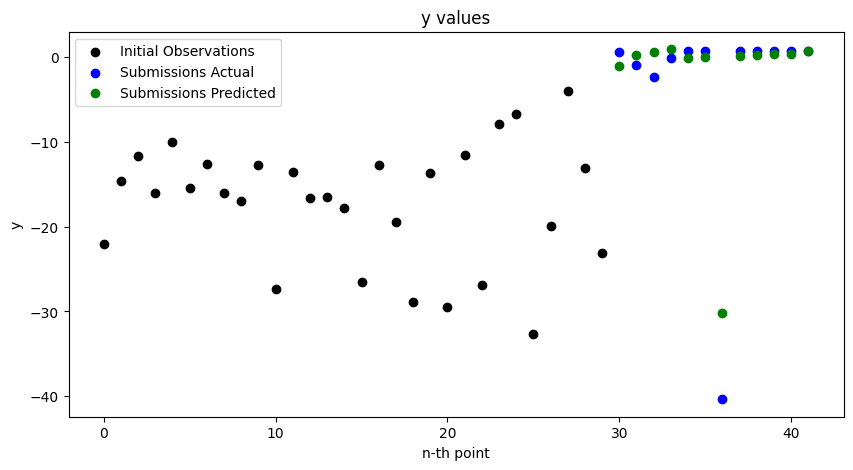

In [12]:
plot_helper.sequence_plot(df["y"], initial_len, y_pred)

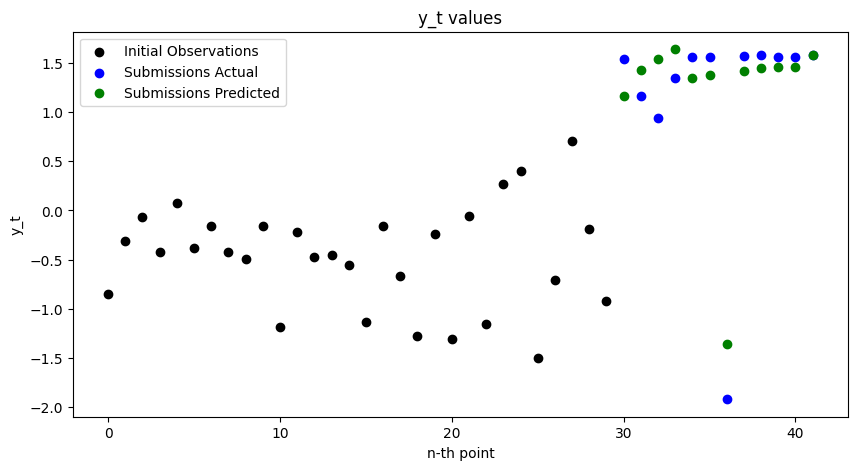

In [13]:
y_t_pred = y_transform.transform(y_pred)
plot_helper.sequence_plot(df["y_t"], initial_len, y_t_pred)

## Determine next evaluation point

### Create grid

In [14]:
x_grid = grid_helper.hypercube_grid([20, 20, 20, 20], x_col_names)

#print(x_grid[0:5])

len(x_grid): 194481


### Maximise UCB and EI acquisition functions

In [15]:
# Small xi (0.0 – 0.01) - Exploitation dominant
# Moderate xi (0.01 – 0.1) - Balanced
# Large xi (0.5+) Strong exploration
ei_xis = [ 2, 1, 0.5, 0.1, 0.05, 0.01, 0.005, 0.001, 0 ]
ucb_betas = [ 10, 5, 2, 1, 0.5, 0.1, 0.05, 0.01, 0 ]
acq_fns = acquisition_fns_helper.get_acq_fns(df, y_transform, ei_xis = ei_xis, ucb_betas = ucb_betas)

# Bespoke bounds to force suggested next x near current x_best:
override_bounds = None # E.g. [(0.5, 0.9), (0.1, 0.4), ...]

if not override_bounds is None:
    display(Markdown(f'<span style="color:red">**Warning: Manually overriding acquisition function optimisation bounds to "{override_bounds}"**</span>'))
    
df_acq_results = acquisition_fns_helper.determine_next_eval_points(df, best_model, x_grid, x_col_names, x_transform, y_transform, x_dim, acq_fns, bounds = override_bounds, opt_trials=1000)

EI trans space (xi=2)...
Acq Fn([0.999999 0.       0.       0.      ]) = 3.2646777249233508e-15, distance: 0.5810533610788761, y_t_best: [-0.56285924], y_best: [-18.6009497]
EI trans space (xi=1)...
Acq Fn([0.999999 0.       0.       0.      ]) = 7.301702708962725e-10, distance: 0.5810533610788761, y_t_best: [-0.56285924], y_best: [-18.6009497]
EI trans space (xi=0.5)...
Acq Fn([0.37918459 0.38383035 0.36151639 0.3522113 ]) = 5.184233361051765e-06, distance: 0.08019895957329161, y_t_best: [1.30886318], y_best: [-0.41676545]
EI trans space (xi=0.1)...
Acq Fn([0.4016254  0.38963194 0.36855477 0.39572192]) = 0.006141565970268877, distance: 0.03450315833566199, y_t_best: [1.49353733], y_best: [0.38748813]
EI trans space (xi=0.05)...
Acq Fn([0.40486818 0.38877384 0.36895008 0.40359114]) = 0.013030705211977741, distance: 0.027038625063060012, y_t_best: [1.52079768], y_best: [0.49189839]
EI trans space (xi=0.01)...
Acq Fn([0.40784698 0.38774782 0.36906829 0.41049215]) = 0.023305025659356625, 

### Display the acquisition function results

In [16]:
display(Markdown(f'<br>**EXISTING BEST:**'))
print(f'Actual y: {df['y'].iloc[0]}\nActual y_t: {df['y_t'].iloc[0]}\nx: {df[x_col_names].iloc[0].values}')

x_t = x_transform.transform(df[x_col_names].iloc[0].values.reshape(-1,x_dim))
y_t_mean, y_t_std = best_model.predict(np.atleast_2d(x_t), return_std=True)
y_mean, y_std = y_transform.inverse_transform_dist(y_t_mean, y_t_std)

display(Markdown(f'<br>**Model\'s [{best_model_name}] prediction at x corresponding to the best y.**'))
print(f'NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.')
print(f'y_t_mean: {y_t_mean}, y_t_std: {y_t_std}\ny_mean: {y_mean}\n')

# Add a y_mean ranking
df_acq_results['y_mean rank'] = df_acq_results['y_mean'].rank(ascending=False, method='min').astype(int)

display(Markdown(f'<br>**FUNCTION {func_no} SUBMISSION WEEK {sub_week}:**<br>'))
print(df_acq_results.to_string(index=False))

<br>**EXISTING BEST:**

Actual y: 0.7025162485725329
Actual y_t: 1.577278758752402
x: [0.420568 0.369889 0.365224 0.420239]


<br>**Model's [Matern 0.5 + WhiteK, x:scaled, y:pow-scaled] prediction at x corresponding to the best y.**

NB. the model was already trained using this x point. This is just a sense check for modelling accuracy rather than predictive ability.
y_t_mean: [1.57727797], y_t_std: [0.00044717]
y_mean: [0.70251348]



<br>**FUNCTION 4 SUBMISSION WEEK 13:**<br>

                     acq_fn            ['x1', 'x2', 'x3', 'x4']     distance  y_t_mean     y_mean  y_mean rank
      EI trans space (xi=2) 0.999999-0.000000-0.000000-0.000000 5.810534e-01 -0.562859 -18.600950           24
      EI trans space (xi=1) 0.999999-0.000000-0.000000-0.000000 5.810534e-01 -0.562859 -18.600950           24
    EI trans space (xi=0.5) 0.379185-0.383830-0.361516-0.352211 8.019896e-02  1.308863  -0.416765           22
    EI trans space (xi=0.1) 0.401625-0.389632-0.368555-0.395722 3.450316e-02  1.493537   0.387488           18
   EI trans space (xi=0.05) 0.404868-0.388774-0.368950-0.403591 2.703863e-02  1.520798   0.491898           17
   EI trans space (xi=0.01) 0.407847-0.387748-0.369068-0.410492 2.088635e-02  1.541253   0.568069           14
  EI trans space (xi=0.005) 0.408262-0.387598-0.369034-0.411350 2.013752e-02  1.543544   0.576501           13
  EI trans space (xi=0.001) 0.408602-0.387476-0.368993-0.412025 1.954705e-02  1.545311   0.582992           12
 

## Manually calculating the prediction at an x point (Helper method)